# Median Filtering

บทนี้อธิบายการกรองภาพด้วย **median filter** ซึ่งเป็นตัวกรองเชิงพื้นที่ (spatial filter) ที่นิยมใช้ลด noise แบบ **salt-and-pepper noise** หรือจุดดำจุดขาวกระจายในภาพ

หัวข้อที่เรียนใน notebook นี้

- แนวคิดของ filtering และ spatial filtering
- หลักการของ median filtering
- เหตุผลที่ median filter เหมาะกับ salt-and-pepper noise
- การใช้ `cv2.medianBlur`
- การเขียน median filter แบบวนลูปเองเพื่อให้เห็นขั้นตอน
- ผลของขนาด kernel ต่อภาพที่ได้


## 1. Spatial Filtering คืออะไร

**Filtering** คือเทคนิคสำหรับปรับปรุงหรือเปลี่ยนแปลงภาพ เพื่อให้ภาพเหมาะกับการใช้งานมากขึ้น เช่น ทำให้ภาพเรียบขึ้น ลด noise ทำให้ภาพคมขึ้น หรือเน้นขอบของวัตถุ ตัวอย่างงานประมวลผลภาพที่ใช้ filtering ได้แก่ **smoothing**, **sharpening** และ **edge enhancement**

**Spatial filtering** คือการกรองภาพในโดเมนเชิงพื้นที่ โดยค่าพิกเซลแต่ละตำแหน่งในภาพผลลัพธ์จะคำนวณจากค่าพิกเซลในบริเวณรอบตำแหน่งเดียวกันของภาพต้นฉบับ บริเวณรอบพิกเซลนี้เรียกว่า **neighborhood** หรือ **window**

ตัวอย่าง window ขนาด `3 x 3`

```text
p1 p2 p3
p4 p5 p6
p7 p8 p9
```

ถ้ากำลังคำนวณค่าของพิกเซลกลาง `p5` ตัวกรองจะนำค่าของพิกเซลใน window นี้มาคำนวณตามวิธีที่กำหนด แล้วแทนค่าพิกเซลกลางด้วยผลลัพธ์ใหม่


## 2. หลักการของ Median Filtering

Median filtering แทนค่าพิกเซลกลางด้วย **ค่ามัธยฐาน (median)** ของค่าพิกเซลใน window

ขั้นตอนสำหรับ window ขนาด `3 x 3`

1. เลือกพิกเซลรอบตำแหน่งที่ต้องการคำนวณ รวมทั้งหมด 9 ค่า
2. เรียงค่าพิกเซลจากน้อยไปมาก
3. เลือกค่าตรงกลางมาเป็นค่าใหม่ของพิกเซลกลาง

ตัวอย่างแนวคิด

```text
ค่าใน window: 10, 12, 11, 250, 13, 10, 12, 11, 13
หลังเรียงค่า: 10, 10, 11, 11, 12, 12, 13, 13, 250
median = 12
```

ค่า `250` เป็นค่าที่สูงผิดปกติ แต่ median ไม่ถูกดึงไปมากเหมือนค่าเฉลี่ย จึงช่วยลด salt-and-pepper noise ได้ดี


## 3. Median Filter เหมาะกับ Noise แบบใด

Median filter เหมาะกับ **salt-and-pepper noise** เพราะ noise ชนิดนี้มักเป็นจุดที่มีค่าสว่างมากหรือมืดมากผิดปกติ เช่น `0` หรือ `255`

ข้อดี

- ลดจุด noise แบบ salt-and-pepper ได้ดี
- รักษาขอบภาพได้ดีกว่า mean filter ในหลายกรณี
- แนวคิดเข้าใจง่าย เพราะใช้ค่ากลางของข้อมูล

ข้อจำกัด

- ใช้เวลาคำนวณมากกว่า mean filter เพราะต้องหาค่ามัธยฐาน
- kernel ขนาดใหญ่เกินไปอาจทำให้รายละเอียดเล็ก ๆ หายไป
- ไม่ได้เหมาะที่สุดกับ noise ทุกชนิด เช่น noise แบบกระจายทั่วภาพอาจต้องใช้วิธีอื่นร่วมด้วย


## 4. Import Library


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


## 5. ฟังก์ชันสำหรับแสดงภาพ

ใช้ `matplotlib.pyplot` แบบพื้นฐาน เพื่อให้นักศึกษาเห็นขั้นตอนชัดเจน ไม่ตั้งค่า style ระดับสูง และไม่ใช้ `plt.rcParams`


In [3]:
def show_image(image, title):
    plt.figure(figsize=(5, 5))
    plt.imshow(image, cmap="gray", vmin=0, vmax=255)
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_images(images, titles):
    count = len(images)
    plt.figure(figsize=(4 * count, 4))

    for i in range(count):
        plt.subplot(1, count, i + 1)
        plt.imshow(images[i], cmap="gray", vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis("off")

    plt.show()


## 6. อ่านภาพแบบ Grayscale

ตัวอย่างนี้ใช้ภาพที่มี salt-and-pepper noise เพื่อให้เห็นผลของ median filter ได้ชัดเจน

การอ่านไฟล์ภาพควรตรวจสอบว่าอ่านสำเร็จหรือไม่ เพราะ `cv2.imread` จะคืนค่า `None` เมื่อ path ผิดหรือไฟล์เสีย ตัวอย่างนี้ใช้ `try/except` และ `raise` แบบตรงไปตรงมา


ชนิดข้อมูล: uint8
ขนาดภาพ: (512, 512)


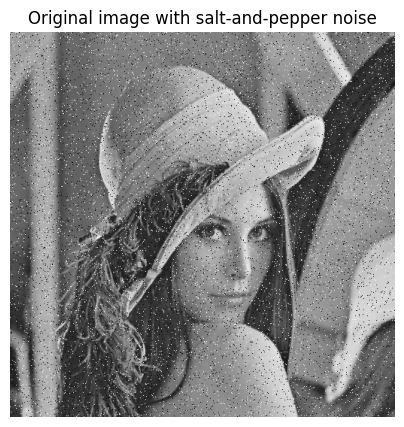

In [4]:
image_path = "./images/lena_salt_512.png"

try:
    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if gray is None:
        raise FileNotFoundError("ไม่พบไฟล์รูปภาพ: " + image_path)

except Exception as error:
    print("เกิดข้อผิดพลาดในการอ่านไฟล์รูปภาพ")
    raise error

print("ชนิดข้อมูล:", gray.dtype)
print("ขนาดภาพ:", gray.shape)

show_image(gray, "Original image with salt-and-pepper noise")


## 7. ทดลองหาค่า Median จากข้อมูลตัวอย่าง

ก่อนกรองภาพจริง ลองดูแนวคิดของ median จากค่าตัวเลขง่าย ๆ ก่อน


In [5]:
values = np.array([10, 12, 11, 250, 13, 10, 12, 11, 13])
sorted_values = np.sort(values)
median_value = np.median(values)

print("ค่าต้นฉบับ:", values)
print("ค่าที่เรียงแล้ว:", sorted_values)
print("median:", median_value)


ค่าต้นฉบับ: [ 10  12  11 250  13  10  12  11  13]
ค่าที่เรียงแล้ว: [ 10  10  11  11  12  12  13  13 250]
median: 12.0


## 8. วิธีที่ 1: ใช้ `cv2.medianBlur`

`cv2.medianBlur` เป็นฟังก์ชันสำเร็จรูปสำหรับ median filtering

ข้อควรจำ

- ค่า `k` คือขนาด kernel เช่น `3`, `5`, `7`
- ค่า `k` ต้องเป็นเลขคี่และมากกว่า `1`
- kernel ขนาดใหญ่ขึ้นจะลด noise ได้มากขึ้น แต่รายละเอียดภาพอาจหายมากขึ้น


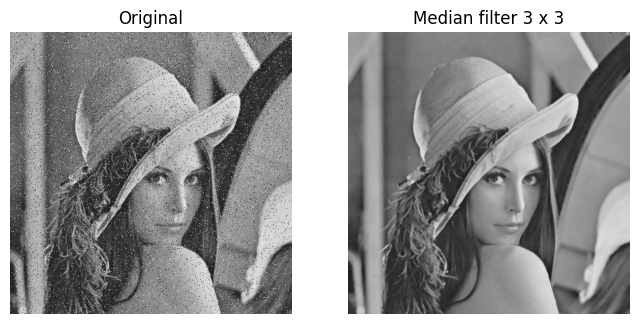

In [6]:
k = 3
median_cv = cv2.medianBlur(gray, k)

show_images(
    [gray, median_cv],
    ["Original", "Median filter 3 x 3"]
)


## 9. วิธีที่ 2: เขียน Median Filter แบบวนลูปเอง

ฟังก์ชันนี้เขียนเพื่อการเรียนการสอน ให้เห็นว่าการกรองภาพเกิดจากการเลื่อน window ไปทีละตำแหน่ง แล้วหาค่า median ในแต่ละ window

เพื่อให้ code สั้นและเข้าใจง่าย ขอบภาพจะคงค่าเดิมไว้ ส่วนพิกเซลด้านในจะคำนวณค่าใหม่


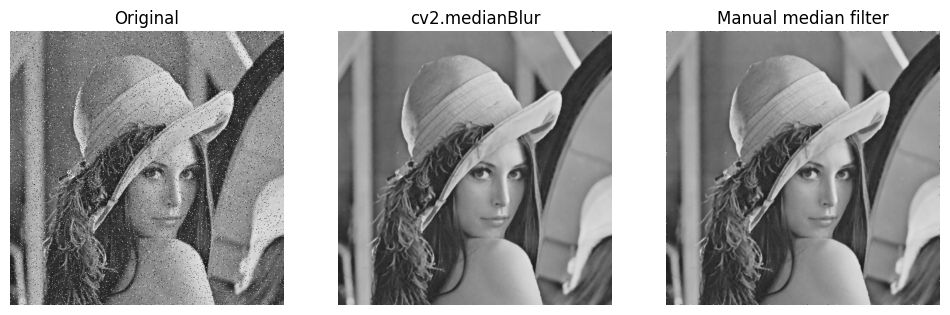

In [7]:
def median_filter_manual(image, k):
    border = k // 2
    height, width = image.shape
    output = image.copy()

    for row in range(border, height - border):
        for col in range(border, width - border):
            area = image[
                row - border : row + border + 1,
                col - border : col + border + 1
            ]
            output[row, col] = int(np.median(area))

    return output


median_manual = median_filter_manual(gray, 3)

show_images(
    [gray, median_cv, median_manual],
    ["Original", "cv2.medianBlur", "Manual median filter"]
)


## 10. เปรียบเทียบ Mean Filter และ Median Filter

เมื่อภาพมี salt-and-pepper noise ค่าเฉลี่ยมักได้รับผลกระทบจากจุดที่สว่างหรือมืดผิดปกติ แต่ median จะเลือกค่ากลางของข้อมูล จึงมักรักษารายละเอียดและลดจุด noise ได้ดีกว่า


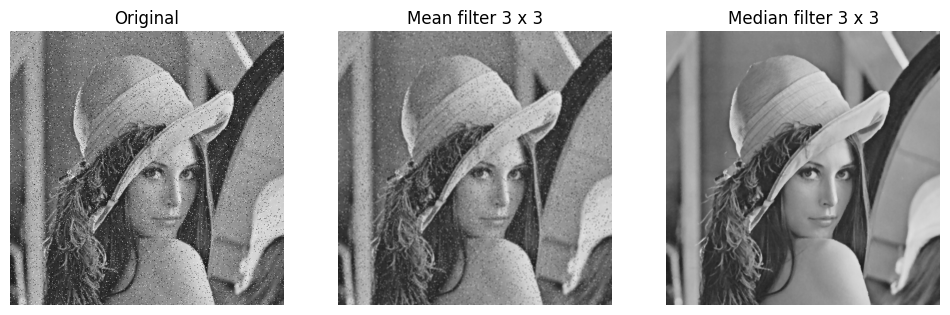

In [8]:
mean_3 = cv2.blur(gray, (3, 3))
median_3 = cv2.medianBlur(gray, 3)

show_images(
    [gray, mean_3, median_3],
    ["Original", "Mean filter 3 x 3", "Median filter 3 x 3"]
)


## 11. เปรียบเทียบผลของขนาด Kernel

ขนาด kernel มีผลต่อระดับการลด noise และรายละเอียดของภาพ

- `3 x 3` ลด noise ได้ระดับหนึ่งและยังรักษารายละเอียดไว้ได้ดี
- `5 x 5` ลด noise ได้มากขึ้น แต่รายละเอียดบางส่วนเริ่มหาย
- `7 x 7` ภาพเรียบขึ้นมาก แต่รายละเอียดเล็ก ๆ อาจหายมากขึ้น


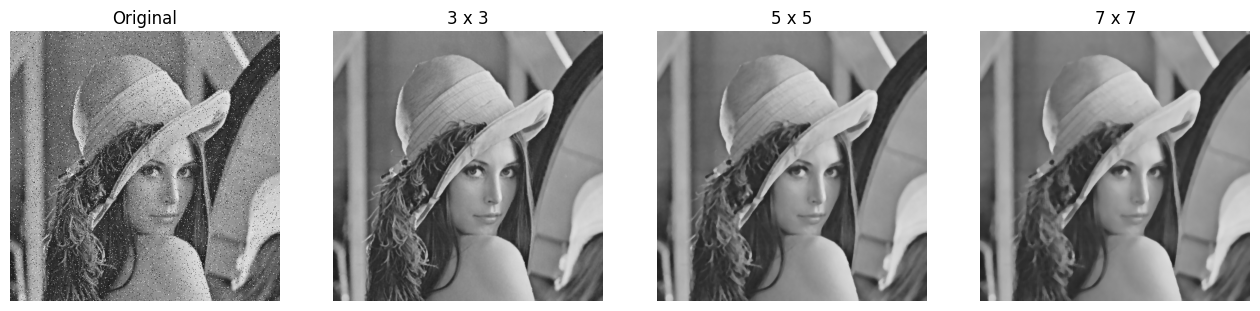

In [9]:
median_3 = cv2.medianBlur(gray, 3)
median_5 = cv2.medianBlur(gray, 5)
median_7 = cv2.medianBlur(gray, 7)

show_images(
    [gray, median_3, median_5, median_7],
    ["Original", "3 x 3", "5 x 5", "7 x 7"]
)


## 12. สรุป

Median filtering เป็นตัวกรองเชิงพื้นที่ที่แทนค่าพิกเซลกลางด้วยค่ามัธยฐานของพิกเซลใน window เหมาะมากกับการลด salt-and-pepper noise เพราะค่ามัธยฐานไม่ไวต่อค่าผิดปกติเท่าค่าเฉลี่ย

สิ่งที่ควรจำ

- median filter ใช้ค่ากลางหลังจากเรียงข้อมูลใน window
- `cv2.medianBlur` ใช้ง่ายและเหมาะกับการใช้งานจริง
- การเขียนวนลูปเองช่วยให้เข้าใจหลักการ แต่ช้ากว่าฟังก์ชันจาก library
- ค่า `k` ต้องเป็นเลขคี่ เช่น `3`, `5`, `7`
- kernel ใหญ่ขึ้นลด noise ได้มากขึ้น แต่รายละเอียดภาพอาจลดลง
